#### NX-414: Brain-like computation and intelligence
Notebook prepared by Alessandro Marin Vargas

# Week 7 - Mini project (Predicting neural activity)

The objectives of the mini project are:
- Learn how to predict neural activity using linear regression from images and from neural network layers.
- Quantify the goodness of the model
- Compare the results across the network layers and between trained/random neural network
- Predict the neural activity using a neural network in a data-driven approach

Specifically, here you will use the data from the following [paper](https://www.jneurosci.org/content/jneuro/35/39/13402.full.pdf). The behavioral experiment consisted in showing to non-human primates some images while recording the neural activity with multielectrode arrays from the inferior temporal (IT) cortex. In the data we provided you, the neural activity and the images are already pre-processed and you will have available the images and the corresponding average firing rate (between 70 and 170 ms) per each neuron.

### Deadline for Mini-Project Submission: May 7, 2025

You are required to submit your mini-projects by midnight on 07/05/25. Please upload a .zip file to Moodle containing your code, along with the following specific components:

- One-Page Report (Report.pdf): This should detail your investigative process and include:
    - A comparison table of models. This should cover linear regression from stimuli, both trained and random task-driven models, data-driven models, and your best-performing model.
    - A figure illustrating the variation in neural prediction across different layers of a task-driven model.
    - Your exploration to develop the most effective model at predicting IT neural activity
- Example Script/Notebook: Please provide a script (test.py) or a notebook (test.ipynb) demonstrating how your best model performs on the validation set. This should serve as an example of the model's usage.

In [1]:
import sys
sys.path.append('./../')
!{sys.executable} -m pip install gdown h5py

In [2]:
from utils import load_it_data, visualize_img
import matplotlib.pyplot as plt
import numpy as np
import gdown
url = "https://drive.google.com/file/d/1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS/view?usp=share_link"
output = "IT_data.h5"
gdown.download(url, output, quiet=False, fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS
From (redirected): https://drive.google.com/uc?id=1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS&confirm=t&uuid=169570c2-1094-43c6-8d27-ccc34a2a9e97
To: /home/nsuresh/NX-414_groupSRN/Week 7/IT_data.h5
100%|███████████████████████████████████████████████████████████████████████████| 384M/384M [00:04<00:00, 95.1MB/s]


'IT_data.h5'

### Load the data

In [3]:
path_to_data = '' ## Insert the folder where the data is, if you download in the same folder as this notebook then leave it blank

stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val = load_it_data(path_to_data)


In [4]:
n_stimulus, n_channels, img_size, _ = stimulus_train.shape
_, n_neurons = spikes_train.shape
print('The dataset contains {} stimuli and {} IT neurons'.format(n_stimulus,n_neurons))
print('Each stimulus have {} channgels (RGB)'.format(n_channels))
print('The size of the image is {}x{}'.format(img_size,img_size))

The dataset contains 2592 stimuli and 168 IT neurons
Each stimulus have 3 channgels (RGB)
The size of the image is 224x224


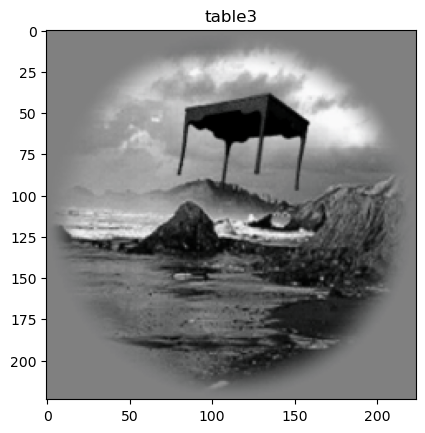

In [5]:
stim_idx = 1

visualize_img(stimulus_train,objects_train,stim_idx)

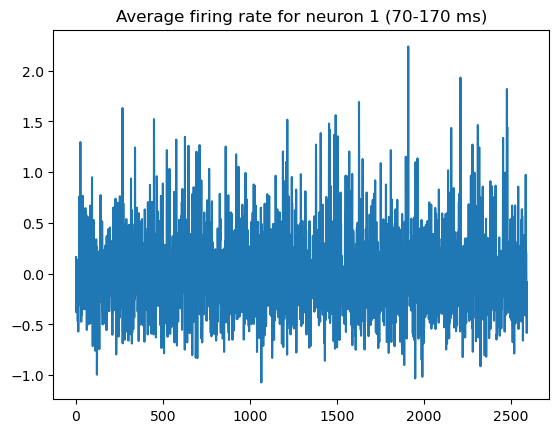

In [6]:
neuron_idx = 1

plt.figure()
plt.title('Average firing rate for neuron {} (70-170 ms)'.format(neuron_idx))
plt.plot(spikes_train[:,neuron_idx])

## Predict the neural activity using a data-driven approach

In the first part of the project, you have predicted the neural activity either from pixels or from the activations of a pre-trained neural network model. Here, your objective is to build and train a shallow convolutional neural network to predict the IT neural activity.

Follow these steps:
- Create the dataloader
- Define the model (Shallow CNN with 2/3 layers)
- Define the loss function (MSE) and the optimizer
- Build the training script and train your model
- Evaluate the predictions of your model. 
- Compare the neural predictions with the ones achieved by the task-trained neural network model. Which one can better predict the neural activity?

In [7]:
!pip install torch torchvision

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader

In [9]:
#Creating DataLoaders
stimulus_train = torch.tensor(stimulus_train, dtype=torch.float32)
spikes_train = torch.tensor(spikes_train, dtype=torch.float32)

stimulus_val = torch.tensor(stimulus_val, dtype=torch.float32)
spikes_val = torch.tensor(spikes_val, dtype=torch.float32)

stimulus_test = torch.tensor(stimulus_test, dtype=torch.float32)

train_dataset = TensorDataset(stimulus_train, spikes_train)
val_dataset = TensorDataset(stimulus_val, spikes_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

In [10]:
#defining shallow CNN with 3 layers ~
class img2spikeCNN(nn.Module):
    def __init__(self):
        super(img2spikeCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(32 * 56 * 56, 168)

    def forward(self, x):
        x = self.pool1(torch.tanh(self.conv1(x)))
        x = self.pool2(torch.tanh(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [11]:
#train the CNN in predicting 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = img2spikeCNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

num_epochs = 40

best_model = model.state_dict()
best_epoch = 1
best_score = 1

for epoch in range(num_epochs):
    #Training
    model.train()
    total_train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    #Validation
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    if avg_val_loss<best_score:
        best_model = model.state_dict()
        best_epoch = epoch + 1
        best_score = avg_val_loss
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    scheduler.step()

print(f"Best epoch {best_epoch} | Lowest validation loss: {best_score:.4f}")


Epoch 1/40 | Train Loss: 1.8584 | Val Loss: 0.1919
Epoch 2/40 | Train Loss: 0.1330 | Val Loss: 0.1251
Epoch 3/40 | Train Loss: 0.0930 | Val Loss: 0.1204
Epoch 4/40 | Train Loss: 0.0765 | Val Loss: 0.1210
Epoch 5/40 | Train Loss: 0.0644 | Val Loss: 0.1212
Epoch 6/40 | Train Loss: 0.0552 | Val Loss: 0.1214
Epoch 7/40 | Train Loss: 0.0481 | Val Loss: 0.1233
Epoch 8/40 | Train Loss: 0.0416 | Val Loss: 0.1262
Epoch 9/40 | Train Loss: 0.0362 | Val Loss: 0.1275
Epoch 10/40 | Train Loss: 0.0320 | Val Loss: 0.1290
Epoch 11/40 | Train Loss: 0.0260 | Val Loss: 0.1295
Epoch 12/40 | Train Loss: 0.0238 | Val Loss: 0.1312
Epoch 13/40 | Train Loss: 0.0220 | Val Loss: 0.1325
Epoch 14/40 | Train Loss: 0.0205 | Val Loss: 0.1336
Epoch 15/40 | Train Loss: 0.0191 | Val Loss: 0.1354
Epoch 16/40 | Train Loss: 0.0178 | Val Loss: 0.1362
Epoch 17/40 | Train Loss: 0.0166 | Val Loss: 0.1376
Epoch 18/40 | Train Loss: 0.0154 | Val Loss: 0.1389
Epoch 19/40 | Train Loss: 0.0143 | Val Loss: 0.1406
Epoch 20/40 | Train L

In [12]:
#checking correlations with true neural activity using the best model
from scipy.stats import pearsonr
from sklearn.metrics import explained_variance_score

model.load_state_dict(best_model)
model.eval()
val_all = None 
y_all = None

with torch.no_grad():
    for X_val, y_val in val_loader:
        X_val, y_val = X_val.to(device), y_val.to(device)
        val_outputs = model(X_val)
        val_np = val_outputs.detach().cpu().numpy()
        y_np = y_val.detach().cpu().numpy()
        if val_all is None:
            val_all = val_np
            y_all = y_np
        else:
            val_all = np.concatenate((val_all,val_np),axis=0)
            y_all = np.concatenate((y_all,y_np),axis=0)

correlations = []
for i in range(y_all.shape[1]):
    corr, _ = pearsonr(y_all[:, i], val_all[:, i])
    correlations.append(corr)
avg_corr_val = np.mean(correlations)

ev_val = explained_variance_score(y_all, val_all)

print(f"Avg correlation of validation outputs and ground truth for the best model = {avg_corr_val}")
print(f"Explained variance of validation outputs and ground truth for the best model = {ev_val}")


Avg correlation of validation outputs and ground truth for the best model = 0.3232990503311157
Explained variance of validation outputs and ground truth for the best model = -0.15181659162044525


Mean correlation : 0.3232990503311157


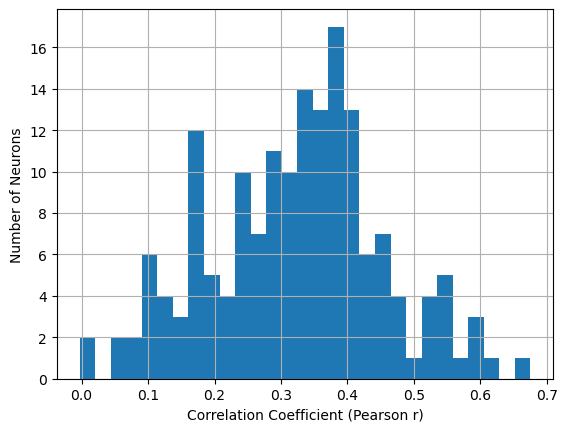

In [14]:
cor_per_neuron = np.array([pearsonr(y_all[:, i], val_all[:, i])[0] for i in range(val_all.shape[1])])
print(f"Mean correlation : {np.mean(cor_per_neuron)}")
    
bins = np.linspace(np.min(cor_per_neuron), np.max(cor_per_neuron), 30)
    
plt.hist(cor_per_neuron, bins=bins)
plt.xlabel('Correlation Coefficient (Pearson r)')
plt.ylabel('Number of Neurons')
plt.grid(True)
plt.show()

Mean explained varianve : -0.15181663632392883


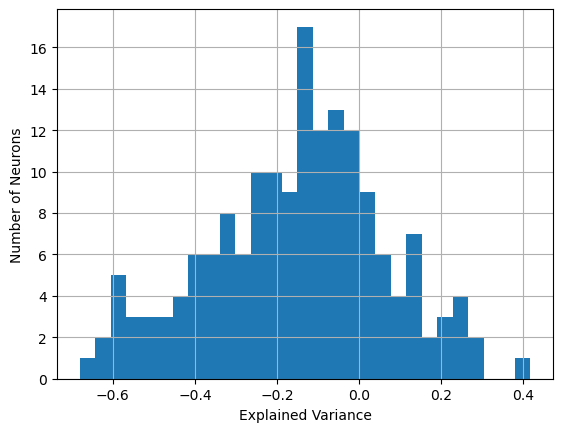

In [16]:
ev_per_neuron = np.array([explained_variance_score(y_all[:, i], val_all[:, i],multioutput='raw_values') for i in range(val_all.shape[1])])
print(f"Mean explained varianve : {np.mean(ev_per_neuron)}")
    
bins = np.linspace(np.min(ev_per_neuron), np.max(ev_per_neuron), 30)
    
plt.hist(ev_per_neuron, bins=bins)
plt.xlabel('Explained Variance')
plt.ylabel('Number of Neurons')
plt.grid(True)
plt.show()

## Comparing the performance of data-driven vs task-driven models

The performance by different layers of the task-driven model are given below: </br>
For conv1, average correlation = 0.2975, average explained variance = 0.098 </br>
For layer1, average correlation = 0.52, average explained variance = 0.26 </br>
For layer2, average correlation = 0.555, average explained variance = 0.311 </br>
For layer3, average correlation = 0.63, average explained variance = 0.40 </br>
For layer4, average correlation = 0.605, average explained variance = 0.37 </br>
For avgpool, average correlation = 0.5477, average explained variance = 0.31 </br>

The shallow data-driven model does not perform as well as the individual layers of the task-driven model. In addition, the task-driven model offers higher interpretability as the later layers can better explain the neural activations implying that better the performance on the task, higher the correlation with neural activations.